In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import tensorflow as tf
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from collections import Counter
from wordcloud import WordCloud
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

In [5]:
# Download NLTK data (if running for the first time)
nltk.download('stopwords', quiet=True)

True

In [10]:
#read dataset
df = pd.read_csv('/content/drive/MyDrive/new drive/Interview task/train.csv')
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [4]:
print("Missing values before drop:\n", df.isnull().sum())

Missing values before drop:
 id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64


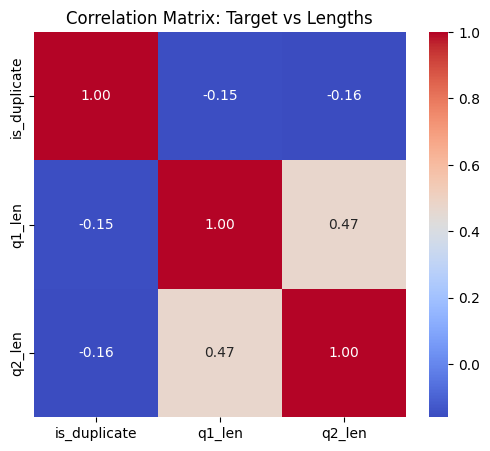

In [12]:
df['q1_len'] = df['question1'].apply(lambda x: len(str(x).split()))
df['q2_len'] = df['question2'].apply(lambda x: len(str(x).split()))

#Correlation Matrix
correlation_matrix = df[['is_duplicate', 'q1_len', 'q2_len']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Target vs Lengths')
plt.show()

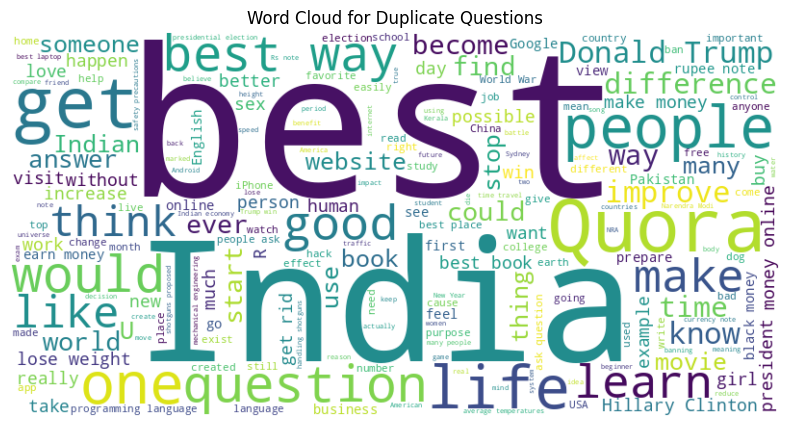

In [18]:
#Word Cloud Visualization
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# Combine text from duplicate questions (where is_duplicate == 1)
duplicate_text = " ".join(df[df['is_duplicate'] == 1]['question1'].astype(str)) + " " + \
                 " ".join(df[df['is_duplicate'] == 1]['question2'].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(duplicate_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Duplicate Questions')
plt.show()

In [19]:
# Configuration TensorFlow

MAX_VOCAB = 10000
MAX_LEN = 30
EMBEDDING_DIM = 50
SAMPLE_SIZE = 20000
print("Imports complete. TensorFlow Version:", tf.__version__)

Imports complete. TensorFlow Version: 2.19.0


In [20]:
# Sampling (optional remove this block to train on full data)
if SAMPLE_SIZE and len(df) > SAMPLE_SIZE:
    df = df.sample(n=SAMPLE_SIZE, random_state=42).dropna().reset_index(drop=True)
    print(f"Data sampled to {SAMPLE_SIZE} rows for efficiency.")
else:
    df = df.dropna().reset_index(drop=True)

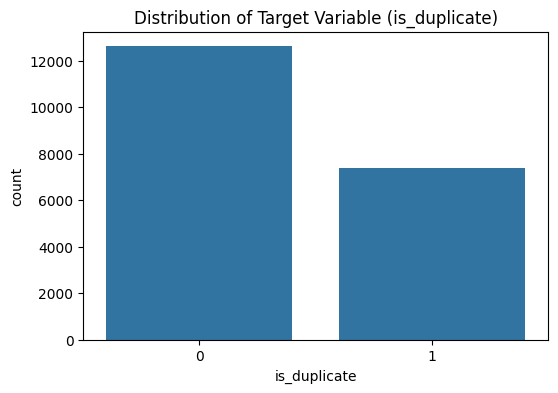

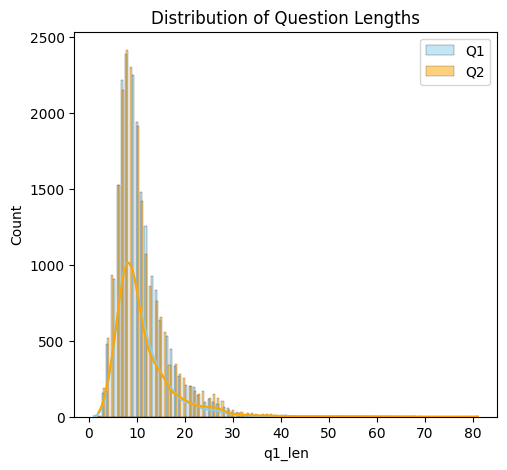

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(x='is_duplicate', data=df)
plt.title('Distribution of Target Variable (is_duplicate)')
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df['q1_len'], kde=True, color='skyblue', label='Q1')
sns.histplot(df['q2_len'], kde=True, color='orange', label='Q2')
plt.title('Distribution of Question Lengths')
plt.legend()

In [22]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

 #convert into lowercase, remove special charecters and tokenzation
def preprocess_text(text):

    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)

    words = [stemmer.stem(w) for w in text.split() if w not in stop_words]
    return " ".join(words)

In [23]:
print("Cleaning text (this may take a moment)...")
df['clean_q1'] = df['question1'].apply(preprocess_text)
df['clean_q2'] = df['question2'].apply(preprocess_text)

Cleaning text (this may take a moment)...


In [24]:
# Tokenization (Keras)
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(pd.concat([df['clean_q1'], df['clean_q2']]))

q1_seq = tokenizer.texts_to_sequences(df['clean_q1'])
q2_seq = tokenizer.texts_to_sequences(df['clean_q2'])

In [25]:
# Padding
q1_pad = pad_sequences(q1_seq, maxlen=MAX_LEN, padding='post', truncating='post')
q2_pad = pad_sequences(q2_seq, maxlen=MAX_LEN, padding='post', truncating='post')

labels = df['is_duplicate'].values
print("Preprocessing complete. Data shape:", q1_pad.shape)

Preprocessing complete. Data shape: (20000, 30)


In [26]:
# Split Data
X_q1_train, X_q1_test, X_q2_train, X_q2_test, y_train, y_test = train_test_split(
    q1_pad, q2_pad, labels, test_size=0.2, random_state=42
)

In [27]:
def build_siamese_model(lstm_units=64, dropout_rate=0.2, learning_rate=0.001):
    # Inputs
    input_q1 = Input(shape=(MAX_LEN,), name='q1_input')
    input_q2 = Input(shape=(MAX_LEN,), name='q2_input')


    embedding = Embedding(input_dim=MAX_VOCAB, output_dim=EMBEDDING_DIM)


    lstm = LSTM(lstm_units)

    encoded_q1 = lstm(embedding(input_q1))
    encoded_q2 = lstm(embedding(input_q2))


    merged = Concatenate()([encoded_q1, encoded_q2])


    x = Dense(lstm_units, activation='relu')(merged)
    x = Dropout(dropout_rate)(x)
    x = BatchNormalization()(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=[input_q1, input_q2], outputs=output)
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [28]:
hyperparams = [
    {'lstm_units': 32, 'dropout': 0.2, 'lr': 0.001},
    {'lstm_units': 64, 'dropout': 0.3, 'lr': 0.001}
  # {'lstm_units': 128, 'dropout': 0.3, 'lr': 0.001}
]

best_model = None
best_acc = 0
best_history = None

print(f"Starting Grid Search on {len(hyperparams)} configurations...")

for i, params in enumerate(hyperparams):
    print(f"\nTraining Config {i+1}: {params}")
    model = build_siamese_model(lstm_units=params['lstm_units'],
                                dropout_rate=params['dropout'],
                                learning_rate=params['lr'])

    history = model.fit(
        [X_q1_train, X_q2_train], y_train,
        epochs=50,
        batch_size=64,
        validation_split=0.1,
        verbose=1
    )

    val_acc = history.history['val_accuracy'][-1]
    if val_acc > best_acc:
        best_acc = val_acc
        best_model = model
        best_history = history
        print(f"Val Acc: {val_acc:.4f}")

print(f"\n Validation Accuracy achieved: {best_acc:.4f}")
print("Best Model Summary:")
best_model.summary()

Starting Grid Search on 2 configurations...

Training Config 1: {'lstm_units': 32, 'dropout': 0.2, 'lr': 0.001}
Epoch 1/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.5956 - loss: 0.6668 - val_accuracy: 0.6375 - val_loss: 0.6223
Epoch 2/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7642 - loss: 0.4918 - val_accuracy: 0.6881 - val_loss: 0.5836
Epoch 3/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.8108 - loss: 0.4144 - val_accuracy: 0.6856 - val_loss: 0.5874
Epoch 4/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8427 - loss: 0.3607 - val_accuracy: 0.7138 - val_loss: 0.7009
Epoch 5/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.8690 - loss: 0.3049 - val_accuracy: 0.6587 - val_loss: 0.7510
Epoch 6/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 37ms/step - accuracy: 0.8790 - loss: 0.2690 - val_accuracy: 0.7081 - val_loss: 0.7898
Epoch 7/50
225/225 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.8866 - loss: 0.2449 - val_accuracy: 0.7075 - 

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ q1_input            │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q2_input            │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 50)    │    500,000 │ q1_input[0][0],   │
│ (Embedding)         │                   │            │ q2_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │     10,624 │ embedding[0][0],  │
│                     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64)        │          0 │ lstm[0][0],       │
│ (Concatenate)       │                   │            │ lstm[1][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32)        │        128 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         33 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,538,469 (5.87 MB)

 Trainable params: 512,801 (1.96 MB)

 Non-trainable params: 64 (256.00 B)

 Optimizer params: 1,025,604 (3.91 MB)

In [29]:
#Predictions
y_pred_probs = best_model.predict([X_q1_test, X_q2_test])
y_pred = (y_pred_probs > 0.5).astype(int)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [30]:
#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.73      0.75      2537
           1       0.58      0.64      0.61      1463

    accuracy                           0.70      4000
   macro avg       0.68      0.69      0.68      4000
weighted avg       0.70      0.70      0.70      4000



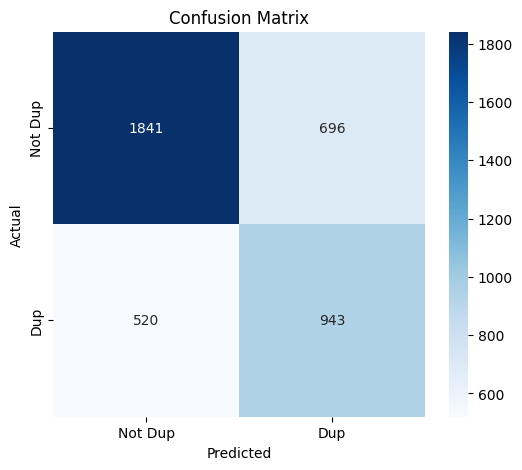

In [31]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Dup', 'Dup'], yticklabels=['Not Dup', 'Dup'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

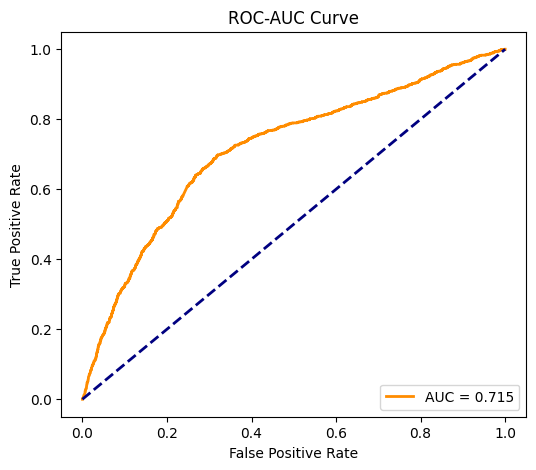

In [32]:
#AUC-ROC Curve
auc = roc_auc_score(y_test, y_pred_probs)
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend(loc="lower right")
plt.show()

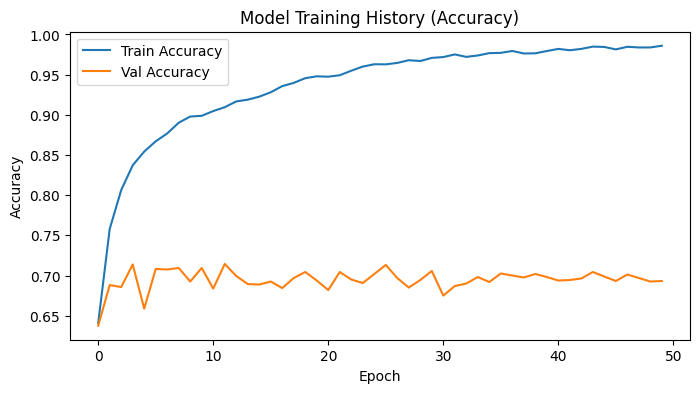

In [33]:
#Model Accuracy Plot (History)
plt.figure(figsize=(8, 4))
plt.plot(best_history.history['accuracy'], label='Train Accuracy')
plt.plot(best_history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Training History (Accuracy)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Applying LOGISTIC **REGRESSION**

**Libraries** and Load data

In [34]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [35]:
df1 = pd.read_csv('/content/drive/MyDrive/new drive/Interview task/train.csv')
df = df.dropna()
df1.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


**Cleaning**

In [36]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)
    text = re.sub(r"\s+", " ", text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return " ".join(words)


In [37]:
df["q1_clean"] = df["question1"].apply(clean_text)
df["q2_clean"] = df["question2"].apply(clean_text)
df["combined"] = df["q1_clean"] + " " + df["q2_clean"]


TF-IDF Feature and **Split**

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df["combined"]).toarray()
y = df["is_duplicate"]


In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Train Logistic **Regression**

In [42]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=300)
log_reg.fit(X_train, y_train)
pred_lr = log_reg.predict(X_test)


In [43]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc = accuracy_score(y_test, pred_lr)
print("Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, pred_lr))

cm = confusion_matrix(y_test, pred_lr)
print("\nConfusion Matrix:\n", cm)


Accuracy: 0.71

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.87      0.79      2537
           1       0.66      0.43      0.52      1463

    accuracy                           0.71      4000
   macro avg       0.69      0.65      0.66      4000
weighted avg       0.70      0.71      0.69      4000


Confusion Matrix:
 [[2212  325]
 [ 835  628]]


Confussion **matrix**

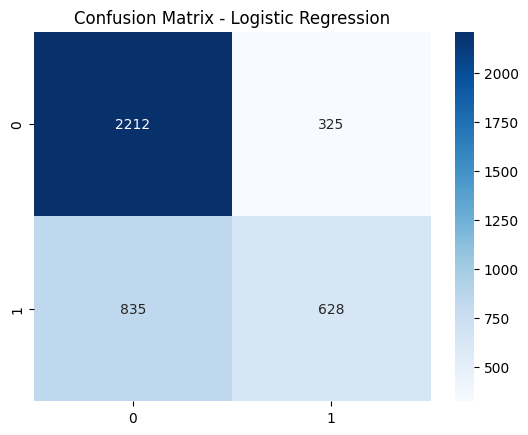

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


ROC-AUC **Score**

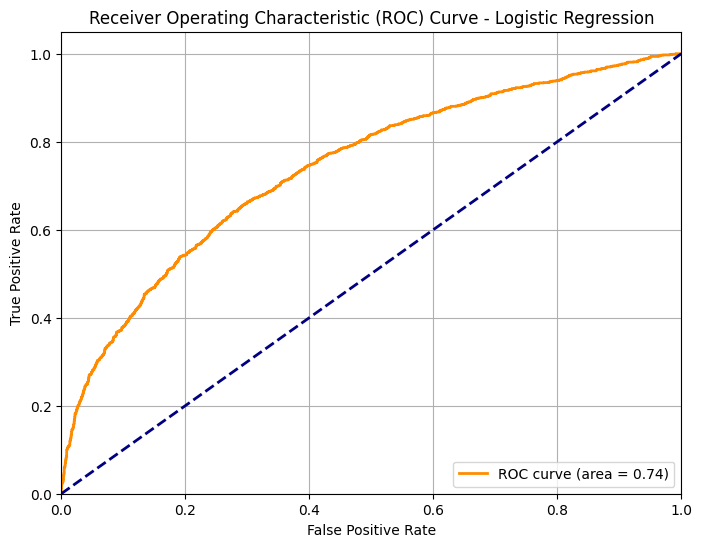

ROC-AUC Score: 0.7410855227796082


In [52]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, pred_lr)
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Logistic Regression')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("ROC-AUC Score:", roc_auc)


# Applying SVM

In [6]:

import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [7]:
df = pd.read_csv('/content/drive/MyDrive/new drive/Interview task/train.csv')
df = df.dropna()
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


**Cleaning**

In [8]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[%s]" % re.escape(string.punctuation), " ", text)
    text = re.sub(r"\s+", " ", text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return " ".join(words)


In [9]:
df["q1_clean"] = df["question1"].apply(clean_text)
df["q2_clean"] = df["question2"].apply(clean_text)
df["combined"] = df["q1_clean"] + " " + df["q2_clean"]

TF-IDF Feature and **Split**

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(df["combined"])
y = df["is_duplicate"]


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


Train **SVM**

In [12]:
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)
pred_svm = svm_model.predict(X_test)


In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

acc = accuracy_score(y_test, pred_svm)
print("Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, pred_svm))

cm = confusion_matrix(y_test, pred_svm)
print("\nConfusion Matrix:\n", cm)


Accuracy: 0.743130950908866

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.85      0.81     51240
           1       0.69      0.55      0.61     29630

    accuracy                           0.74     80870
   macro avg       0.73      0.70      0.71     80870
weighted avg       0.74      0.74      0.74     80870


Confusion Matrix:
 [[43762  7478]
 [13295 16335]]


Confusion **Matrix**

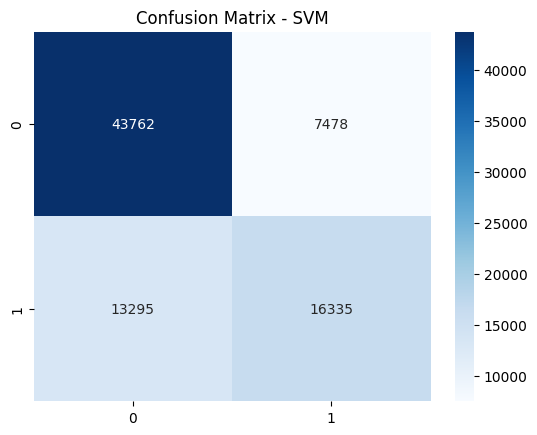

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()

ROC-AUC **Score**

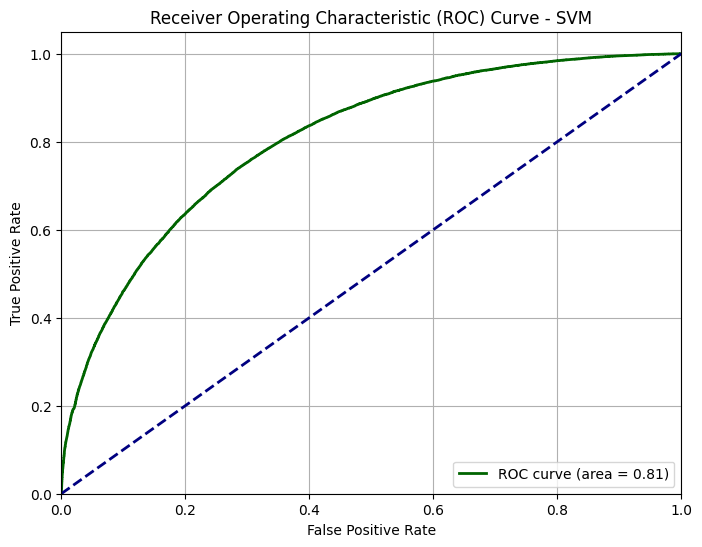

ROC-AUC Score: 0.8056193814922161


In [17]:
from sklearn.metrics import roc_auc_score

svm_scores = svm_model.decision_function(X_test)
roc = roc_auc_score(y_test, svm_scores)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkgreen', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - SVM')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
print("ROC-AUC Score:", roc)
